как улучшить данные до обработки? мы знаем что поле "зеленое" и занимает большую часть кадра
мы знаем что линии белые. также известно что линии "узкие" и не содержат внутри других цветов: если взять точки 
 поэтому есть смысл рассматривать переходы только между белым и зеленым цветом.




In [1]:
# %pip install opencv-python imageio 


In [2]:
# filed detection
import cv2
from numba.experimental import jitclass
import matplotlib.pyplot as plt
# from imageio.core.imopen import imopen
from numpy.ma.core import shape
import numpy as np

# img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename

def init_image_to_process():
    input_video_path = "../materials_part1/2024-11-18 17-53-16.mkv"#"../2024-11-18 17-53-16.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"  #"F:\\Videos\\2024-11-18 17-49-57.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"
    
    cap = cv2.VideoCapture(input_video_path)
    
    from cut_image import get_cut_frame_from_frame
    
    ret, image = cap.read()
    for _ in range(100):
        ret, image = cap.read()
        if not ret:
            pass
        
    image = get_cut_frame_from_frame(image, 2)
    image = cv2.rotate(image, cv2.ROTATE_180)
    img_tmp = cv2.blur(image, (3, 3))
    cv2.imwrite("../tmp/hehe4.png", img_tmp)

def init_image_to_process2():
    input_img = "../datasets/test/cam0/4.png"
    
    image = cv2.imread(input_img)
    image = cv2.rotate(image, cv2.ROTATE_180)
    # img_tmp = cv2.blur(image, (3, 3))
    cv2.imwrite("../tmp/hehe4.png", image)

init_image_to_process2()



# image = cv2.blur(image, (3, 3))
# image = cv2.blur(image, (3, 3))
# img = cluster_and_recolor(image, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# print(img)
# img = cluster_and_recolor(img,4)
# cv2.imshow('lanes', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


from sklearn.cluster import KMeans


# flat = img.flatten()
def multiply_list(data):
    tmp = 1
    for i in data:
        tmp *= i
    return tmp


def cluster_and_recolor(img, n_clusters, mode: int = 1, top_n=None, binary=False):
    flat = img.reshape((multiply_list(img.shape) // 3, 3))

    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=3).fit(flat)

    cluster_color_centers = list()
    for i in kmeans.cluster_centers_:
        clr = list()
        for j in i:
            clr.append(int(j))
        cluster_color_centers.append(clr)
    cluster_color_centers = np.array(cluster_color_centers)
    # print(img, "hehe", flat, type(img), "hehe", cluster_color_centers)

    unflat = kmeans.labels_.reshape(img.shape[:-1]).astype(np.uint8)

    if mode == 1:
        return unflat * (255 // n_clusters)
    elif mode == 2 or mode == 3:
        sizes = [0] * len(cluster_color_centers)
        for i in kmeans.labels_:
            sizes[i] += 1
        tmp_sizes = list()
        for num, i in enumerate(sizes):
            tmp_sizes.append((-i, num))
        tmp_sizes = sorted(tmp_sizes)
        remap = [0] * len(sizes)
        for num, i in enumerate(tmp_sizes):
            remap[i[1]] = num
        if mode == 3:
            start_clr = cluster_color_centers[tmp_sizes[0][1]]
            size = tmp_sizes[0][0]
            if top_n is None:
                top_n = 0
            seen = [tmp_sizes[0][1]]
            for i in range(top_n):
                nearest = 0
                dist = np.inf
                size_tmp = 0
                for j in range(n_clusters):
                    if tmp_sizes[j][1] not in seen and np.linalg.norm(
                            start_clr - cluster_color_centers[tmp_sizes[j][1]]) < dist:
                        dist = np.linalg.norm(start_clr - cluster_color_centers[tmp_sizes[j][1]])
                        nearest = tmp_sizes[j][1]
                        size_tmp = tmp_sizes[j][0]
                seen.append(nearest)
                #start_clr = size * (start_clr / (size_tmp + size)) + cluster_color_centers[nearest] * (size_tmp / (size_tmp + size))
                size += size_tmp
            for j in seen:
                remap[j] = seen[0]
        for i in range(len(unflat)):
            for j in range(len(unflat[i])):
                if top_n is None or (mode == 3 and not binary):
                    unflat[i][j] = remap[unflat[i][j]]
                elif binary and mode == 3:
                    if remap[unflat[i][j]] == remap[tmp_sizes[0][1]]:
                        unflat[i][j] = 255
                    else:
                        unflat[i][j] = 0
                elif top_n > remap[unflat[i][j]]:
                    unflat[i][j] = 255
                else:
                    unflat[i][j] = 0
        if top_n is None or mode == 3:
            return unflat * (255 // n_clusters)
        else:
            return unflat
    elif mode == 4:
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                img[i][j] = cluster_color_centers[unflat[i][j]]
        return img


# image = cv2.blur(image, (3, 3))
# image = cv2.blur(image, (3, 3))
# img = cluster_and_recolor(image, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# print(img)
# img = cluster_and_recolor(img,4)
# cv2.imshow('lanes', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [3]:
#lines detection
from image_tuner import rgb_tune_test, tune_from_params, rgb_tune_from_params
import numpy as np
import math
from numba import jit
import sklearn.cluster as skcl
from scipy.spatial import ConvexHull
from sklearn.linear_model import LinearRegression

import cv2


def remove_squares(image,ratio = 5.0,debug=False,mask_only=False):
    """
    this function removes things that are more square-like in terms of proportions
    :param image: image
    :param ratio: all boxes with sides ratio 1/ratio< x <ratio  will be removed
    """
    # Бинаризация изображения
    binary = None
    if len(image.shape)>2:        
        binary = cv2.Canny(image,50,150)
    else:
        _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    # Поиск контуров
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Создание маски
    mask = np.zeros_like(image)

    # Пороги для фильтрации
    aspect_ratio_min = 1/ratio  # Минимальное аспектное соотношение
    aspect_ratio_max = ratio  # Максимальное аспектное соотношение
    image_area = image.shape[0]*image.shape[1]
    area_min = 1/10000*image_area       
    area_max = 1/100*image_area        

    # Обработка контуров
    for contour in contours:
        # Получаем размеры ограничивающего прямоугольника
        x, y, w, h = cv2.boundingRect(contour)

        # Вычисляем аспектное соотношение
        aspect_ratio = float(w) / h if h != 0 else 0

        # Вычисляем площадь
        # area = cv2.contourArea(contour)
        area = w*h

        # Если это прямоугольник, заливаем его
        if len(image.shape)==2:
            if aspect_ratio_min < aspect_ratio < aspect_ratio_max and area_max> area > area_min:
                # cv2.drawContours(mask, [contour], -1, 255, -1)
                mask = cv2.rectangle(mask, (x,y), (x+w,y+h), 255, -1)
        else:
            if aspect_ratio_min < aspect_ratio < aspect_ratio_max and area_max> area > area_min:
                print(f"found: {x,y,w,h}")
                mask = cv2.rectangle(mask, (x,y), (x+w,y+h), (255,255,255), -1)
                # cv2.drawContours(mask, [contour], -1, (255,255,255), -1)

    # Применяем маску к изображению
    if debug:
        print("remove_squares: mask for squares")
        plt.figure()
        plt.imshow(mask)
        plt.show()

    if mask_only:
        return mask
    result = image.copy()
    result[mask == 255]=0
    return result


# white_color_img = tune_test("../tmp/hehe4.png")  #69 0 153 191 248 255
img_tmp = cv2.imread("../tmp/hehe4.png")
img_tmp = cv2.resize(img_tmp,(700,700)) # we should resize to some standart resolution so in linesearch arguments are the same, because otherwise it finds shorter lines 
# # img_tmp = cv2.imread("/root/Downloads/corridor_field.jpg")
# green_color_img = cv2.blur(img_tmp, (3, 3))
# green_color_img = cluster_and_recolor(green_color_img, 12, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# green_color_img = remove_squares(green_color_img)


# white_color_img = cv2.blur(img_tmp, (5, 5))
# white_color_img = tune_from_params(white_color_img, 33, 0, 143, 181, 76, 255)
# white_color_img = remove_squares(white_color_img)

# cv2.imshow('green image', green_color_img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# rgb_tune_test("/root/Downloads/corridor_field.jpg")
# green_color_img = cluster_and_recolor(green_color_img, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# white_color_img = tune_from_params(img_tmp, 33, 0, 143, 181, 76, 255)
# green_color_img = tune_from_params(img_tmp,23,113,58,36,255,154)
# white_color_img = rgb_tune_from_params(img_tmp,57,104,117,117,124,137)
# print(white_color_img.shape,len(white_color_img),len(white_color_img[0]))
# cv2.imshow('white image', white_color_img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

@jit
def get_result_edges(white_color_img_i, green_color_img_i,params=(1,2,14)):# _i for internal
    """
    computes edges from 2 images: on one only white(preferably only lines),on other only green


    params: 
    for seen_white and seen_green in 3x3 kernel of pixel:
    if seen_white > param[0] and seen_green > param[1] and (seen_white + seen_green) < param[2]: then edge
    """
    # result_edges_i = white_color_img_i * 0
    result_edges_i = np.zeros(white_color_img_i.shape, dtype="uint8")
    for i in range(1, len(white_color_img_i) - 1):
        for j in range(1, len(white_color_img_i[i]) - 1):
            seen_white = 0
            seen_green = 0
            bad = 0
            for k in (-1, 0, 1):
                for t in (-1, 0, 1):
                    if green_color_img_i[i + k][j + t] > 200:
                        seen_green += 1
                    if white_color_img_i[i + k][j + t] > 200:
                        seen_white += 1
                    if green_color_img_i[i + k][j + t] <= 200 and white_color_img_i[i + k][j + t] <= 200:
                        bad += 1
            if seen_white > params[0] and seen_green > params[1] and (seen_white + seen_green) < params[2]:
                # print("lane")
                result_edges_i[i][j] = 255
    return  result_edges_i



def get_edges_wrapper(img,debug=False,blur_param =2):
    green_color_img = img
    for i in range(blur_param):
        green_color_img = cv2.blur(green_color_img, (3, 3))#todo move out this params

    green_color_img = cluster_and_recolor(green_color_img, 12, 3, top_n=2, binary=True)  #todo moveout this params
    green_color_img = remove_squares(green_color_img)

    white_color_img = img
    for i in range(blur_param):
        white_color_img = cv2.blur(white_color_img,(3,3))
    # white_color_img = cv2.blur(img, (5, 5)) #todo: move out this params
    white_color_img = tune_from_params(white_color_img, 33, 0, 143, 181, 76, 255) #todo: move out this params
    white_color_img = remove_squares(white_color_img)

    if debug:
        plt.figure()
        plt.imshow(green_color_img)
        plt.show()
        plt.figure()
        plt.imshow(white_color_img)
        plt.show()

    result_edges = get_result_edges(white_color_img,green_color_img)
    return result_edges


def get_edges_canny(img,debug=False,blur_param = 2):
    mask = remove_squares(img,mask_only=True,debug=debug)

    for i in range(blur_param):
        img = cv2.blur(img,(3,3))
    edges = cv2.Canny(img,50,120)
    if len(mask.shape)==3:
        edges[mask[:,:,0]!=0] = 0
    else:
        edges[mask!=0]=0
    if debug:
        print("canny: edges")
        plt.figure()
        plt.imshow(edges)
        plt.show()
    return edges

if False: # this is working code
    result_edges = get_edges_wrapper(img_tmp)
    print("end prep")

    analysis = cv2.connectedComponentsWithStats(result_edges,
                                                4,
                                                cv2.CV_32S)
    (totalLabels, label_ids, values, centroid) = analysis
    areas = list()
    for i in values:
        areas.append(i[cv2.CC_STAT_AREA])
    areas = sorted(areas, reverse=True)
    output = np.zeros(result_edges.shape, dtype="uint8")
    for i in range(1, totalLabels):
        area = values[i, cv2.CC_STAT_AREA]

        if area >= areas[min(30,len(areas)-1)]:
            # Labels stores all the IDs of the components on the each pixel 
            # It has the same dimension as the threshold 
            # So we'll check the component 
            # then convert it to 255 value to mark it white 
            componentMask = (label_ids == i).astype("uint8") *255#* int(i/totalLabels*255)
            # print(i/totalLabels)

            # Creating the Final output mask 
            output = cv2.bitwise_or(output, componentMask)
        # print (analysis)
    cv2.imwrite("../tmp/hehe6.png",output)
    # cv2.imshow('lanes', output)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    segments = cv2.HoughLinesP(output, 1, math.pi / 180, 80, 30, 40) #cv2.HoughLinesP(image, rho, theta, threshold, minLineLength, maxLineGap)
    # segments = cv2.HoughLinesP(output, 1, math.pi / 180, 80, 60, 40) #cv2.HoughLinesP(image, rho, theta, threshold, minLineLength, maxLineGap)
    # print(segments.shape,segments)
    segments = segments.reshape((len(segments), 2, 2))

    # segments[i] = sorted(segments[i])
    lines = list()

if False:  #clusterization method   #todo redo segments from vec<int,4> to vec<vec<int,2>,2>
    segm_by_direction_and_sp = list()
    for i_tmp in segments:
        i = i_tmp[0]
        x = i[2] - i[0]
        y = i[3] - i[1]
        if True:
            len_xy = math.sqrt(x * x + y * y)
            x /= len_xy
            y /= len_xy
        if x < 0:
            x *= -1
            y *= -1
        zero = (0, 0)
        if abs(x) > abs(y):
            c1 = i[0] / x
            zero = (0, i[1] - y * c1)
        else:
            c1 = i[1] / y
            zero = (i[0] - x * c1, 0)
        segm_by_direction_and_sp.append((x * 1000, y * 1000, zero[0], zero[1]))
    segm_by_direction_and_sp = np.array(segm_by_direction_and_sp)
    # clusters = skcl.OPTICS(min_samples=4).fit(segm_by_direction_and_sp)
    # clusters = skcl.DBSCAN(min_samples=2).fit(segm_by_direction_and_sp)
    clusters = skcl.HDBSCAN(min_samples=2).fit(segm_by_direction_and_sp)
    # clusters = KMeans(n_clusters=10).fit(segm_by_direction_and_sp)
    centers_of_clusters = dict()
    for i in range(len(segm_by_direction_and_sp)):
        if clusters.labels_[i] not in centers_of_clusters.keys():
            centers_of_clusters[clusters.labels_[i]] = [np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])]
            # print(type(segm_by_direction_and_sp[i].tolist()),,centers_of_clusters[clusters.labels_[i]])
            centers_of_clusters[clusters.labels_[i]].extend(
                (segm_by_direction_and_sp[i] * np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])).tolist())
        else:
            centers_of_clusters[clusters.labels_[i]][0] += np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])
            for j in range(len(segm_by_direction_and_sp[i])):
                centers_of_clusters[clusters.labels_[i]][j + 1] += segm_by_direction_and_sp[i][j] * np.linalg.norm(
                    segments[i][0][:1] - segments[i][0][2:])
    for i in centers_of_clusters.values():
        # print(i)
        # i = [1]
        # i.extend(i_tmp)
        lines.append([[int((i[-2] - 1000 * i[1]) / i[0]), int((i[-1] - 1000 * i[2]) / i[0]),
                    int((i[-2] + 1000 * i[1]) / i[0]), int((i[-1] + 1000 * i[2]) / i[0])]])

#idea: if 2 segments are on line then area on 4 points is minimal


if False:
    for i in range(len(segments)):  #sorted so segms are from x1 to x2 where x1<x2 or x1==x2 and y1<y2
        if segments[i][0][0] < segments[i][1][0]:
            segments[i] = np.array([segments[i][1], segments[i][0]])
        elif segments[i][0][0] == segments[i][1][0] and segments[i][0][1] < segments[i][1][1]:
            segments[i] = np.array([segments[i][1], segments[i][0]])

    st = set()
    for i in segments:
        st.add(tuple(i.reshape((4)).tolist()))
    while True:
        # concatinating segments by using best start and best end points while area metric allows it
        first_best = second_best = None
        best_area = 0
        for i_tmp in st:
            for j_tmp in st:
                i = np.array(i_tmp)
                j = np.array(j_tmp)
                if (i != j).any():
                    area = 0
                    points = np.array([i, j]).reshape((4, 2))
                    for i in range(len(points)):
                        area += np.cross(points[i], points[(i + 1) % len(points)])

                    if first_best is None:
                        first_best = i
                        second_best = j
                        best_area = area
                    else:
                        if best_area > area:
                            best_area = area
                            first_best = i
                            second_best = j
        if area > 500:
            break

        points = np.array([first_best, second_best]).reshape((2, 4))
        line = LinearRegression().fit(points[0], points[1])
        start = (0, line.intercept_)
        direction = (1, line.coef_)


        def project_point(point, start_line, direction_line):
            point -= start_line
            sk = 0
            len_line = 0
            for i in range(len(line)):
                len_line += direction_line[i] ** 2
                sk += direction_line[i] * point[i]
            sk /= len_line
            return start_line + direction_line * sk


        result = (0, 0)
        if first_best[0] < second_best[0]:
            result[0] = first_best[0]
        else:
            result[0] = second_best[0]
        if first_best[0] > second_best[0]:
            result[1] = first_best[1]
        else:
            result[1] = second_best[1]
        result[0] = project_point(result[0], start, direction)
        result[1] = project_point(result[1], start, direction)
        st.remove(first_best)
        st.remove(second_best)
        st.add(np.array(result))
    lines = list(st)

#idea 3: same as idea 2, but using this metric in dbscan
#todo: we probably should remove too small segments or note that we dont want to join 2 very distant segments if they very distant, but by chance are on same line, lets
#say that (a-b distance)*((1/len(a))+(1/len(b)))
labels = 0
n_clusters = 0
@jit
def cross2d(x, y):
    return np.array([x[..., 0] * y[..., 1] - x[..., 1] * y[..., 0]])

@jit
def custom_distance_v1(a: np.array, b: np.array):  # works iff a and b goes into different directions
    a = a.reshape((2, 2))
    b = b.reshape((2, 2))
    points = [a[0], a[1], b[0], b[1]]
    sum = cross2d(points[-1], points[0])
    for i in range(1, len(points)):
        sum += cross2d(points[i - 1], points[i])
    return np.linalg.norm(sum)  #eps = 10

@jit
def custom_distance_v2(a: np.array, b: np.array):
    a = a.reshape((2, 2))
    b = b.reshape((2, 2))
    points = [a[0], a[1], b[0], b[1]]
    sum = cross2d(points[-1], points[0])
    for i in range(1, len(points)):
        sum += cross2d(points[i - 1], points[i])
    points[0], points[1] = points[1], points[0]
    sum2 = cross2d(points[-1], points[0])
    for i in range(1, len(points)):
        sum2 += cross2d(points[i - 1], points[i])
    return max(np.linalg.norm(sum), np.linalg.norm(sum2))  #eps = 100

@jit
def custom_distance_v3(a: np.array, b: np.array):
    a = a.reshape((2, 2))
    b = b.reshape((2, 2))
    points = [a[0], a[1], b[0], b[1]]
    sum = cross2d(points[-1], points[0])
    for i in range(1, len(points)):
        sum += cross2d(points[i - 1], points[i])
    points[0], points[1] = points[1], points[0]
    sum2 = cross2d(points[-1], points[0])
    for i in range(1, len(points)):
        sum2 += cross2d(points[i - 1], points[i])
    return max(np.linalg.norm(sum), np.linalg.norm(sum2)) / (
                np.linalg.norm(a[0] - a[1]) + np.linalg.norm(b[0] - b[1]))  #eps = 5


if False:#this is working, commented out for speedup
    # print(segments)
    clustering = skcl.DBSCAN(eps=5, min_samples=1, metric=custom_distance_v3).fit(
        segments.reshape((segments.shape[0], 4)))
    labels = clustering.labels_
    n_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
    # print("labels,cluster_n ",labels,n_clusters)


def add_up_segments_v1(data: np.array):
    data = data.astype(np.float64)

    #prepare
    # def is_same_direction(a,b):
    #     v1 = np.cross(b-a[0],a[1]-a[0])/np.linalg.norm(a[1]-a[0])*(a[1]-a[0]).reshape((1,2))
    #     delta = np.linalg.norm((a[1]-a[0])-(v1[1]-v1[0]))
    #     return delta<1e-5
    # def is_same_direction_v2(a,b):
    #     v1 = np.cross(b-a[0],a[1]-a[0])/np.linalg.norm(a[1]-a[0])
    #     delta = 1-(v1[1]-v1[0])
    #     return delta<1e-5
    def is_same_direction_v3(a, b):
        return np.dot(a[1] - a[0], b[1] - b[0]) > 0

    # print(is_same_direction_v3(np.array([[1,2],[3,4]]),np.array([[9,10],[7,8]])))#false
    # print(is_same_direction_v3(np.array([[1,2],[3,4]]),np.array([[5,6],[7,8]])))#true
    for i in range(1, len(data)):
        if not is_same_direction_v3(data[0], data[i]):
            data[i][0], data[i][1] = data[i][1], data[i][0]
    sum_weight = np.linalg.norm(data[0][1] - data[0][0])
    sum_direction = data[0][1] - data[0][0]
    avg_point = (data[0][0] + data[0][1]) * sum_weight
    for i in range(1, len(data)):
        tmp_w = np.linalg.norm(data[i][1] - data[i][0])
        sum_direction += data[i][1] - data[i][0]
        avg_point += (data[i][0] + data[i][1]) * tmp_w
        sum_weight += tmp_w
    sum_direction /= sum_weight
    avg_point /= sum_weight * 2
    start = 0
    end = 0
    for i in range(len(data)):
        start = min(start, np.dot(sum_direction, data[i][0] - avg_point))
        end = max(end, np.dot(sum_direction, data[i][1] - avg_point))
    return (np.array([start * sum_direction, end * sum_direction]) + avg_point).astype(np.int32)

if False: #this is working 
    grouped = dict()
    for i in range(len(segments)):
        if labels[i] not in grouped.keys():
            grouped[labels[i]] = [segments[i]]
        else:
            grouped[labels[i]].append(segments[i])
    if True:
        new_segments = list()
        for i in grouped.values():
            new_segments.append(add_up_segments_v1(np.array(i)))
        segments = new_segments


In [4]:

from homography_matrix import homography_matrix_v2

In [5]:

# segments = list()
# tttmpsegm = segments
# segments = segments[:2]
# print(segments)
# print(segments)
# segments = [np.array([[0,0],[0,100]]),np.array([[1,0],[2,100]])]
# segments = [np.array([[0,0],[100,0]]),np.array([[0,1],[100,2]])]

# segments = list()
# for i in range(10):
#     i *=30
#     segments.append(np.array([[0,i*1],[-1000,3*i]])+np.array([1000,0]))
# for i in range(10):
#     i*=30
#     segments.append(np.array([[i*1,0],[3*i,1000]]))#+np.array([0,1000]))

from horizon_point import get_horizon_point,horizon_point_optimization_loss_v2



from scipy.optimize import minimize
hor_points = list()
segs_groups = list()
if True and False:
    # print(len(segments))
    to_remove = set()
    for i in range(4):
        print('-'*100)
        new_segments = list()
        rev_map = dict()
        for j in range(len(segments)):
            if j not in to_remove:
                rev_map[len(new_segments)] = j
                new_segments.append(segments[j].astype(np.float64))
        val,point,segs_tmp = get_horizon_point(new_segments,9e-1)# here is setting for eps
        segs = set()
        for j in segs_tmp:
            segs.add(rev_map[j])
        segs_groups.append(segs)
        print(val,segs)
        segs_real = list()
        for j in segs:
            segs_real.append(segments[j].astype(np.float64))
        print("before opt: ",point,horizon_point_optimization_loss_v2(point,segs_real))
        opt_res = minimize(horizon_point_optimization_loss_v2,point,segs_real, method = 'Nelder-Mead')
        # print(opt_res)
        point = opt_res.x
        # print(point,type(point))
        print("after opt: ",point,horizon_point_optimization_loss_v2(point,segs_real))
        for j in segs:
            to_remove.add(j)
        hor_points.append(point)
    print(hor_points)

# segments = tttmpsegm

            








In [ ]:


def center_and_rescale(segments,target_shape,debug=False,scale_type="max"):
    """
    takes segments and returns homography that helps center them to center of image and scale them to size of screen
    :param scale_type: "max" or "avg": scales with this along x and y
    """
    avg = np.array([0,0]).astype(np.float64)
    for i in segments:
        avg+=i[0]+i[1]
    avg/=(2*len(segments))
    if debug:
        print(f"moved by -average: {-avg}")
    max_diff = 0
    target_max_diff = np.linalg.norm(np.array(target_shape)/2)
    for i in range(len(segments)):
        segments[i]-=avg
        max_diff = max(max_diff,np.linalg.norm(segments[i]))
    if debug:
        print(f"then scaled with coeff: {target_max_diff/max_diff}, i.e. by max diff of current point and max axis")
    for i in range(len(segments)):
        segments[i]*=target_max_diff/max_diff
        segments[i]+=np.array([target_shape[1],target_shape[0]])/2
    if debug:
        print(f"then moved by {np.array([target_shape[1],target_shape[0]])/2}, i.e. by half of image size")
        print(segments)
    ###### apply found values
    from homography_matrix import homography_move_v,homography_scale_s#homography @ homography = homography
    new_hompgraphy_matrix = homography_move_v(np.array([target_shape[1],target_shape[0]])/2)@\
                            homography_scale_s(target_max_diff/max_diff)@\
                            homography_move_v(-avg)

    return new_hompgraphy_matrix

if True and False:
    # output_2 = cv2.warpPerspective(img_tmp,matrix,(3000,3000))
    output_2 = np.copy(output)
    output_2 *=0
    # for i in range(len(segs_groups)):
    #     for j in segs_groups[i]:
    #         output_2 = cv2.line(output_2, segments[j][0], segments[j][1], 255*(1-i/(len(segs_groups)*2)))

    distortion_angle = 2*math.pi/180
    mat = homography_matrix_v2(hor_points[1],hor_points[0],np.array(output_2.shape)//2,angle_between_lines=math.pi/2-distortion_angle)
    from homography_matrix import convert_by_homography_mat,homography_shear_angle
    #transforming points
    print("-----------------------------transformation of points--------------------------")
    new_points_after_perspective_transform = list()
    print(f"transformed with matrix using matmul: {mat}")
    for i in segments:
        new_points_after_perspective_transform.append(np.array([convert_by_homography_mat(j,mat) for j in i]))
    new_hompgraphy_matrix = homography_shear_angle(np.array([0,1]),-distortion_angle)@center_and_rescale(new_points_after_perspective_transform,output_2.shape)@mat

    # print(output_2.shape)
    print(new_hompgraphy_matrix)



# cv2.imshow('lanes', cv2.warpPerspective(img,new_hompgraphy_matrix,(700,700)))
# cv2.waitKey(0)
# cv2.destroyAllWindows()
    # output_2*=0
    # for i in new_points_after_perspective_transform:
    #     output_2 = cv2.line(output_2, list(map(int,i[0])), list(map(int,i[1])), 255)
    # black_lines = output_2.copy()
    # output_2 = cv2.resize(output_2,(700,700))
    # cv2.imshow('l', output_2)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()


if True and False:
    output_2 = cv2.imread("../tmp/hehe4.png")
    output_2 = cv2.resize(output_2,(700,700))
    print("new hom matrix",new_hompgraphy_matrix)
    output_2 = cv2.warpPerspective(output_2, new_hompgraphy_matrix,(output_2.shape[1],output_2.shape[0]))
    # output_2 = cv2.resize(output_2,(700,700))
    cv2.imwrite("../tmp/hehe7.png",output_2)
    import matplotlib.pyplot as plt
    plt.figure()
    plt.imshow(output_2)
    plt.show()


In [7]:
#prepare image for circle search: remove found lines
if True and False:
    img = cv2.imread('../tmp/hehe7.png')
    for i in segments:
        i = [convert_by_homography_mat(j,new_hompgraphy_matrix) for j in i]
        #make lines longer:
        i_v = i[1]-i[0]
        i = np.array([i[0]-i_v*200,i[0]+i_v*200])
        img = cv2.line(img, list(map(int,i[0])), list(map(int,i[1])), 0,20)
    import matplotlib.pyplot as plt
    plt.figure()
    plt.imshow(img)
    plt.show()
    cv2.imwrite("../tmp/hehe8.png",img)
    


hough transform v1 (circles) major idea: it uses only edges

In [8]:
import copy
# from http.cookiejar import debug

import numpy as np
import cv2
from skimage.draw import ellipse
from sympy.physics.units import current

# Read image
img = cv2.imread('../tmp/hehe8.png')

# Convert the image to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Find the edges in the image using canny detector
img = cv2.medianBlur(img, 5)
edges = cv2.Canny(img, 50, 200)
# img = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
edges = cv2.cvtColor(cv2.imread('../tmp/hehe8.png'),cv2.COLOR_BGR2GRAY)

# Detect points that form a line
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 68, minLineLength=15, maxLineGap=250)
circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, 1, 100, param1=50, param2=30, minRadius=0, maxRadius=0)
print(circles)
# if circles is None:
#     raise RuntimeError("no circles found")
# circles = np.uint16(np.around(circles))
# for i in circles[0, :]:
#     # draw the outer circle
#     img = cv2.circle(img, (i[0], i[1]), i[2], 255, 2)
#     # draw the center of the circle
#     img = cv2.circle(img, (i[0], i[1]), 2, 255, 3)
#lines = cv2.HoughLinesP(edges, 1, np.pi/180, minLineLength=10, maxLineGap=250)
# Draw lines on the image
# for line in lines:
#     x1, y1, x2, y2 = line[0]
#     cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
# Show result
# cv2.imshow('lanes', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

[[[313.5 281.5 280.9]
  [193.5 341.5 196.7]
  [418.5 262.5 291.9]
  [137.5 228.5 136.5]
  [422.5 142.5 411.7]
  [318.5 411.5 150.9]
  [224.5 638.5 133.9]
  [168.5 444.5 129.2]
  [ 83.5 513.5  88.8]
  [423.5 404.5 146.1]
  [ 25.5 679.5 105.1]
  [325.5 585.5  82.1]
  [410.5 670.5 120.3]
  [206.5  56.5 130.9]
  [  4.5  82.5  73.4]
  [ 32.5 415.5  53.7]
  [127.5 611.5  78.5]
  [412.5 531.5  29.3]
  [299.5 110.5 104.2]
  [238.5 528.5  23.9]
  [ 93.5 324.5  61.1]
  [106.5  95.5  35.5]
  [  7.5 197.5  32.2]
  [562.5 528.5  87.6]]]


hough transform v2 (ellipses)

In [9]:
from find_ellipse import FindEllipseRHT

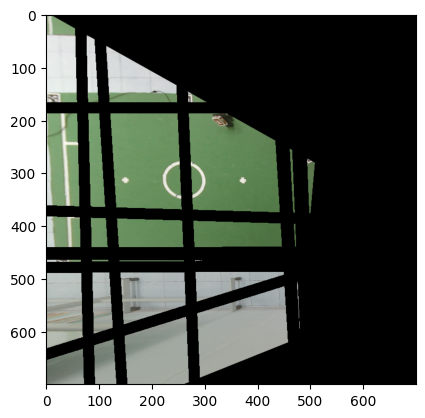

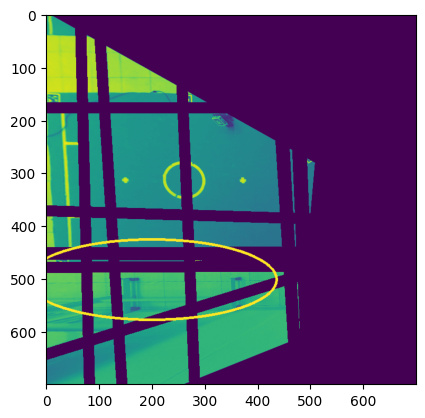

In [10]:
import time
import cv2
import matplotlib.pyplot as plt
import numpy as np

original_image_path = "../tmp/hehe8.png"
original_image = cv2.imread(original_image_path)  #"../tmp/v5_bacground.png"
# print(original_image.shape)
# original_image = cv2.blur(original_image, (5, 5))

# from image_tuner import rgb_tune_from_params
# original_image = rgb_tune_from_params(original_image, 216, 212, 204, 255, 255, 255)  # 128, 167, 196, 255, 255, 255)
# original_image = cv2.resize(original_image, (256,256), interpolation=cv2.INTER_LINEAR)
# original_image = cv2.blur(original_image, (3, 3))
# print(original_image)

plt.figure()
plt.imshow(original_image)
plt.show()
original_image = cv2.cvtColor(original_image,cv2.COLOR_RGB2GRAY)
mask_binary = np.zeros(original_image.shape, dtype=bool)
mask_binary[original_image == 255] = False
mask_binary[original_image != 255] = True

time1 = time.time()
test = FindEllipseRHT(original_image, mask_binary)

test.max_iter = 200
test.score_threshold = 10
data = test.run(plot_mode=False, debug_mode=False)

def find_ellipse_slow_wrapper(img,debug=False):
    mask_binary = np.zeros(img.shape, dtype=bool)
    mask_binary[img == 255] = False
    mask_binary[img != 255] = True
    test = FindEllipseRHT(img, mask_binary)
    test.max_iter = 200000
    test.score_threshold = 10
    data = test.run(plot_mode=debug, debug_mode=debug)
    return data[0][0]

best = data[0][0]
for i in range(len(best)):
    best[i] = int(best[i])
delta = 0.2
# original_image*=0
# original_image+=255
# original_image = cv2.ellipse(original_image, best[0:2], (int(best[2] * (1 - delta)), int(best[3] * (1 - delta))),
#                              data[0][0][4], 0, 360, (0, 0, 0), -1)
# mask = cv2.ellipse(np.zeros_like(original_image), best[0:2], (int(best[2] * (1 + delta)), int(best[3] * (1 + delta))),
#                    data[0][0][4], 0, 360, (255, 255, 255), -1)
original_image = cv2.ellipse(original_image,list(map(lambda xx: int(xx),data[0][0][0:2])),list(map(lambda xx: int(xx),data[0][0][2:4])),data[0][0][4],0,360,(255,255,255),3)

plt.figure()
plt.imshow(original_image)
plt.show()


Processing image: tmp.png
The number of output arc-support line segments: 55
The number of arc-support groups: 44
The number of initial ellipses: 20
The number of ellipse candidates: 16
edge pixel number: 20304
Edge image saved to output_edge_image.png
Gradient vectors saved to output_gradient_vectors.txt
Candidate ellipses saved to output_candidate_ellipses.txt
Processing complete.
no_nearest/n_point_sample: 0.344, no_distance/n_point_sample: 0.096,penalty/((a+b)*4): 24.86072341794685 
no_nearest/n_point_sample: 0.32, no_distance/n_point_sample: 0.046,penalty/((a+b)*4): 23.412791113110263 
no_nearest/n_point_sample: 0.353, no_distance/n_point_sample: 0.05,penalty/((a+b)*4): 17.581483858901144 
no_nearest/n_point_sample: 0.426, no_distance/n_point_sample: 0.047,penalty/((a+b)*4): 42.249122662009476 
no_nearest/n_point_sample: 0.205, no_distance/n_point_sample: 0.0,penalty/((a+b)*4): 0.0 
no_nearest/n_point_sample: 0.188, no_distance/n_point_sample: 0.005,penalty/((a+b)*4): 1.7530482832

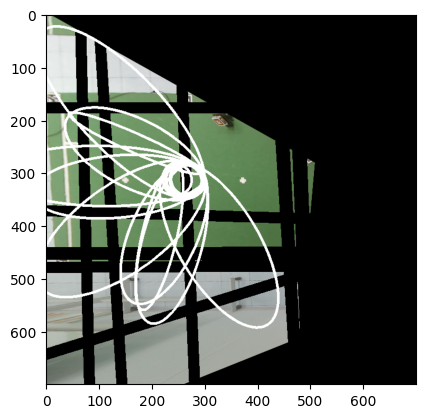

In [11]:
# lets try to find ellipse using code in c++(c)
from ellipse_metrics import metric_by_mask,metric_by_near_segments_base
from find_ellipse import find_ellipses_fast
import matplotlib.pyplot as plt
# import numpy as np
img = cv2.imread("../tmp/hehe8.png")
# img = cv2.warpPerspective(img,new_hompgraphy_matrix,(700,700))
# ellipses = find_ellipses_fast(cv2.blur(img,(3,3)))
def find_ellipse_fast_wrapper(img,debug=False):
    edges = img
    if len(img.shape)>2:
        edges = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(edges,100,200)
    else:
        for i in range(2):
            img = cv2.blur(img,(3,3))
    ellipses = find_ellipses_fast(img)
    ordered = []
    for i in ellipses:
        # metric = metric_by_points(i[0],i[1],i[2],i[3],i[4],cv2.cvtColor(img,cv2.COLOR_RGB2GRAY).astype(int))
        # print(img.shape)

        # metric = metric_by_mask(i[0],i[1],i[2],i[3],i[4],img.astype(np.uint8),width=3)
        metric = metric_by_near_segments_base(i[0],i[1],i[2],i[3],i[4],edges.astype(np.uint8),debug=debug)
        ordered.append([i,metric])
    ordered.sort(key=lambda x:-x[1])
    if debug:
        print(ordered)
        for j in ordered[0:]:
            i = j[0]
            img = cv2.ellipse(img,list(map(lambda xx: int(xx),i[0:2])),list(map(lambda xx: int(xx),i[2:4])),i[4]/(np.pi)*180,0,360,(255,255,255),3)
        plt.figure()
        plt.imshow(img)
        plt.show()
    
    if len(ordered)<1 or (len(ordered)==1 and ordered[0][0][3]==0.0):
        raise RuntimeError("ellipse not found")

    return ordered[0][0]
ellipses = []
try:
    ellipses = [find_ellipse_fast_wrapper(img,debug=True)]
except:
    pass


In [12]:
#now lets try to get params to unsquish image.

def get_transform_from_ellipse(x_0, y_0, a, b, angle,new_rad = 10):
    """
    first 5 are ellipse params,
    :new_rad: is new radius in pixels of our circle
    :return: homography matrix that centers image on x_0, y_0 and transforms that ellipse is now circle with radius 
    """
    angle_delta = abs(angle- int(angle/(math.pi/2))*(math.pi/2))
    if angle_delta>1e1:
        pass #here we should do something, because our image at this point should be rectangle oriented parallel to edges of image
    if abs(angle- int(angle/(math.pi))*(math.pi)) > math.pi/8:
        a,b = b,a #ellipse oriented perpendicularally to our expectations
    from homography_matrix import homography_move, homography_scale
    # rotation = homography_rotate(angle) # we may rotate image so ellipse will be parallel to axies, but we will believe that it is already good enough
    return homography_scale(new_rad/a,new_rad/b)@homography_move(-x_0,-y_0)
    # raise NotImplementedError()#todo
    

if True and len(ellipses)>0 and False:
    final_matrix = get_transform_from_ellipse(ellipses[0][0],ellipses[0][1],ellipses[0][2],ellipses[0][3],ellipses[0][4],60)@new_hompgraphy_matrix
    
    img_tmp = cv2.imread("../tmp/hehe4.png")
    img_tmp = cv2.resize(img_tmp,(700,700))
    img_tmp = cv2.warpPerspective(img_tmp,final_matrix,(700,700))
    plt.figure()
    plt.imshow(img_tmp)
    plt.show()

cell below is one big todo

(1080, 1920, 3)
found: (448, 689, 14, 11)
found: (218, 678, 30, 22)
found: (572, 677, 38, 23)
found: (471, 672, 10, 8)
found: (134, 661, 17, 39)
found: (653, 635, 47, 55)
found: (459, 581, 7, 8)
found: (506, 575, 23, 74)
found: (448, 564, 22, 39)
found: (491, 563, 11, 15)
found: (446, 560, 5, 12)
found: (454, 555, 8, 11)
found: (458, 551, 33, 41)
found: (210, 550, 41, 45)
found: (457, 548, 11, 10)
found: (581, 531, 39, 19)
found: (435, 525, 10, 39)
found: (455, 522, 13, 27)
found: (443, 515, 6, 9)
found: (445, 513, 16, 26)
found: (428, 488, 24, 42)
found: (625, 485, 75, 65)
found: (667, 442, 25, 64)
found: (339, 425, 14, 13)
found: (84, 391, 82, 59)
found: (664, 376, 36, 28)
found: (682, 354, 18, 16)
found: (511, 341, 12, 10)
found: (666, 299, 8, 9)
found: (648, 293, 52, 36)
found: (332, 277, 21, 16)
found: (637, 271, 6, 14)
found: (264, 267, 7, 10)
found: (262, 267, 13, 23)
found: (255, 263, 12, 17)
found: (251, 248, 11, 19)
found: (262, 247, 52, 24)
found: (606, 245, 8, 19)
found: (6

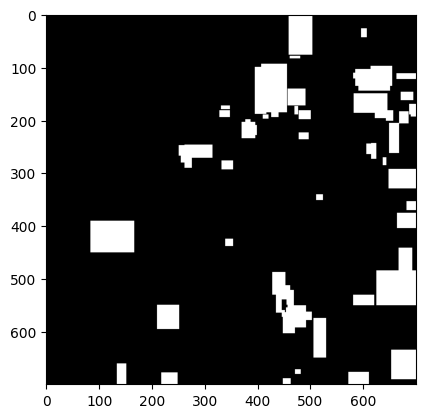

canny: edges


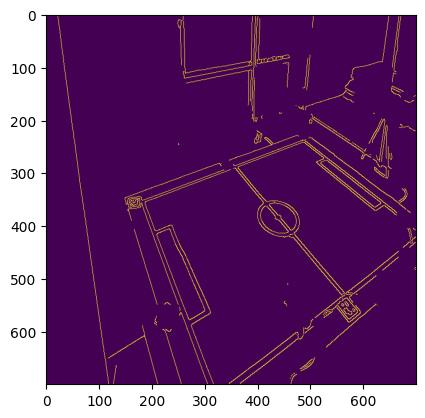

source contours


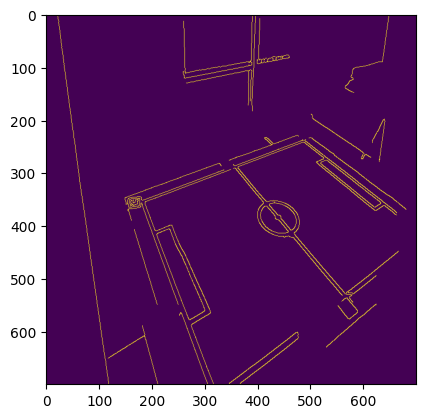

found lines


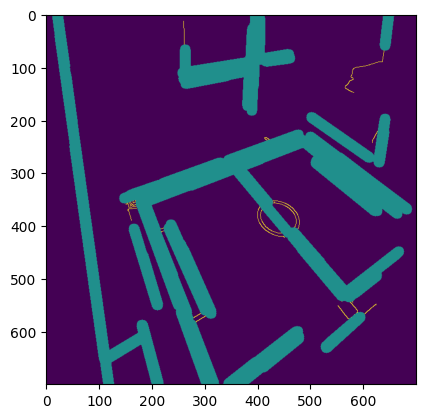

9 {0, 2, 4, 7, 8, 9, 12, 15, 20}
before opt:  [-5.44445129e-02 -1.36621949e+02] 10.161738275501543
after opt:  [   0.53141126 -140.29424211] 6.990413746468976
8 {3, 5, 6, 10, 11, 18, 19, 23}
before opt:  [1337.06589353  -79.01701027] 5.3454639094950895
after opt:  [1323.63507652  -69.88758544] 4.61860707514745
5 {13, 17, 21, 22, 24}
before opt:  [ 348.14418143 2409.21719897] 6.719558816453005
after opt:  [ 328.20544419 2309.3634584 ] 4.950256232965443
3 {16, 1, 14}
before opt:  [ -25.21730934 -176.73886924] 2.9561915483000556
after opt:  [ -20.20909959 -169.10907879] 1.7567903982136295
[array([   0.53141126, -140.29424211]), array([1323.63507652,  -69.88758544]), array([ 328.20544419, 2309.3634584 ]), array([ -20.20909959, -169.10907879])]
h and p3 596.872717132335 471.0314530809308 [  25.02970559 -470.36596776]
-----------------------------transformation of points--------------------------
transformed with matrix using matmul: [[-1.15701060e+00 -3.88816692e-01 -1.96126684e+00]
 [-3.94

/home/alice/Desktop/Camera-accuracy-studies/utils/horizon_point/point_optimization.py:29: RuntimeWarning: invalid value encountered in arccos
  ans += np.tan(np.abs(np.arccos(np.abs(np.dot(direction,direction2)))))*length


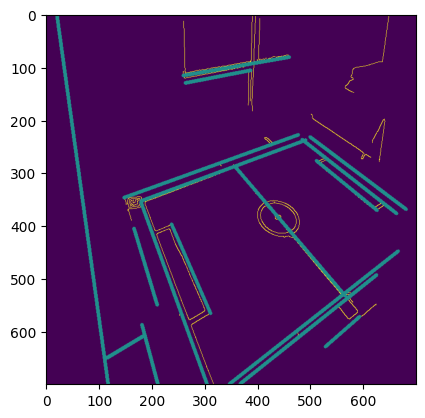

converted lines


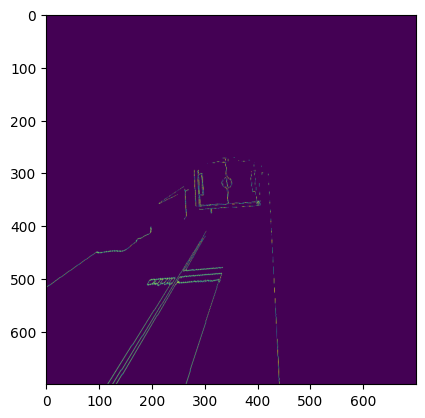

Processing image: tmp.png
The number of output arc-support line segments: 14
The number of arc-support groups: 13
The number of initial ellipses: 0
edge pixel number: 1082
Edge image saved to output_edge_image.png
Gradient vectors saved to output_gradient_vectors.txt
Candidate ellipses saved to output_candidate_ellipses.txt
Processing complete.
[[[0.0, 0.0, 0.0, 0.0, 0.0], 0]]


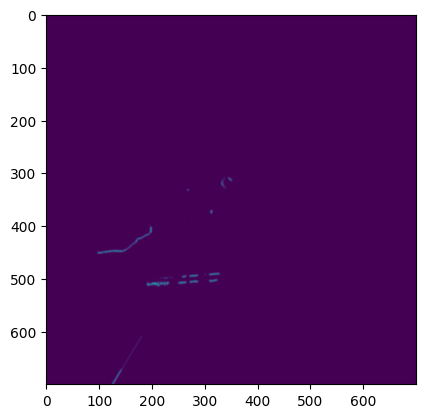

RuntimeError: ellipse not found

In [16]:
def final_pipeline(img,edge_detection = get_edges_wrapper,segments_cluster=custom_distance_v3,optimization_loss=horizon_point_optimization_loss_v2,ellipse_search_function=find_ellipse_fast_wrapper,debug=False):
    """
    this function takes image and some other parameters and returns matrix to convert image to bird-view
    :param img: image
    :param segments_cluster: how we know if segments we found are on same line and we should join them, None if you believe it is already good. for signature look at default function
    :param optimization_loss: how we should optimize found horizon points. for signature look at default function. if None than no optimization
    :param debug: print some (probably unuseful) info about success of function
    """
    ###################################################image process##########################################
    matrix = np.identity(3)
    img_tmp = cv2.resize(img,(700,700)) # we should resize to some standart resolution so in linesearch arguments are the same, because otherwise it finds shorter lines 
    # img_tmp = cv2.imread("/root/Downloads/corridor_field.jpg")
    # img[:,:,0]*=0
    # img[:,:,2]*=0
    result_edges = edge_detection(img_tmp,debug=True,blur_param=2)

    (totalLabels, label_ids, values, centroid) = cv2.connectedComponentsWithStats(result_edges,4,cv2.CV_32S)

    areas = list()
    for i in values:
        areas.append(i[cv2.CC_STAT_AREA])
    areas = sorted(areas, reverse=True)
    output = np.zeros(result_edges.shape, dtype="uint8")
    for i in range(1, totalLabels):
        area = values[i, cv2.CC_STAT_AREA]
        if area >= areas[min(30,len(areas)-1)]: #todo: is it hyperparameter?
            # Labels stores all the IDs of the components on the each pixel 
            # It has the same dimension as the threshold 
            # So we'll check the component 
            # then convert it to 255 value to mark it white 
            componentMask = (label_ids == i).astype("uint8") *255
            # Creating the Final output mask 
            output = cv2.bitwise_or(output, componentMask)
    if debug:
        print("source contours")
        plt.figure()
        plt.imshow(output)
        plt.show()
    #todo: how good is image? need metric.
    ###############################################################segments#####################
    output_tmp_2 = cv2.blur(output,(3,3))
    # output_tmp_2 = cv2.blur(output_tmp_2,(5,5))
    segments = cv2.HoughLinesP(output_tmp_2, 1, math.pi / 180, 80, 30, 40)  #todo: move out this hyperparameters
    segments = segments.reshape((len(segments), 2, 2))
    lines = list()

    if debug:
        print("found lines")
        plt.figure()
        output_tmp = output.copy()
        for i in segments:
            output_tmp = cv2.line(output_tmp,list(map(int,i[0])), list(map(int,i[1])), 127,20)
        plt.imshow(output_tmp)
        plt.show()
    #todo: how good are segments? need metric
    if segments_cluster is not None:
        clustering = skcl.DBSCAN(eps=5, min_samples=1, metric=segments_cluster).fit(
            segments.reshape((segments.shape[0], 4)))
        labels = clustering.labels_
        n_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)

        grouped = dict()
        for i in range(len(segments)):
            if labels[i] not in grouped.keys():
                grouped[labels[i]] = [segments[i]]
            else:
                grouped[labels[i]].append(segments[i])
                
        new_segments = list()
        for i in grouped.values():
            new_segments.append(add_up_segments_v1(np.array(i)))
        segments = new_segments

    hor_points = list()
    segs_groups = list()
    to_remove = set()
    for i in range(4): #todo: hyperparam
        if debug:
            print("="*100)
        new_segments = list()
        rev_map = dict()
        for j in range(len(segments)):
            if j not in to_remove:
                rev_map[len(new_segments)] = j
                new_segments.append(segments[j].astype(np.float64))
        val,point,segs_tmp = get_horizon_point(new_segments,9e-1)# here is setting for eps
        segs = set()
        for j in segs_tmp:
            segs.add(rev_map[j])
        segs_groups.append(segs)
        if debug:
            print(val,segs)
        segs_real = list()
        for j in segs:
            segs_real.append(segments[j].astype(np.float64))
        if debug:
            print("before opt: ",point,optimization_loss(point,segs_real))
        opt_res = minimize(optimization_loss,point,segs_real, method = 'Nelder-Mead')
        point = opt_res.x
        if debug:
            print("after opt: ",point,optimization_loss(point,segs_real))
        for j in segs:
            to_remove.add(j)
        hor_points.append(point)
    if debug:
        print(hor_points)
    distortion_angle = 0
    mat = None
    for i in range(70):
        try:
            distortion_angle = (i*1)*math.pi/180
            mat = homography_matrix_v2(hor_points[1],hor_points[0],np.array(output.shape)//2,angle_between_lines=math.pi/2-distortion_angle,debug=debug)
            break
        except Exception as ex:
            if debug:
                print(ex)
            pass
    if mat is None:
        raise RuntimeError("something wrong with base reprojection")
    from homography_matrix import convert_by_homography_mat,homography_shear_angle
    #transforming points
    if debug:
        print("-----------------------------transformation of points--------------------------")
    new_points_after_perspective_transform = list()
    if debug:
        print(f"transformed with matrix using matmul: {mat}")
    target_segments = list()
    for i in segs_groups[:2]:
        for j in i:
            target_segments.append(segments[j])
    if debug:
        tmp = output.copy()
        for i in target_segments:
            # i = [convert_by_homography_mat(j,new_hompgraphy_matrix) for j in i]
            #make lines longer:
            # i_v = i[1]-i[0]
            # i = np.array([i[0]-i_v*200,i[0]+i_v*200])
            tmp = cv2.line(tmp, list(map(int,i[0])), list(map(int,i[1])), 127,5)
        print("selected to rescale to")
        plt.figure()
        plt.imshow(tmp)
        plt.show()
    for i in target_segments:
        new_points_after_perspective_transform.append(np.array([convert_by_homography_mat(j,mat) for j in i]))
    new_hompgraphy_matrix = homography_shear_angle(np.array([0,1]),-distortion_angle)@center_and_rescale(new_points_after_perspective_transform,output.shape)@mat
    output = cv2.warpPerspective(output,new_hompgraphy_matrix,(700,700))
    if debug:
        print("converted lines")
        plt.figure()
        plt.imshow(output)
        plt.show()
    ###########################prepare image for ellipse search###################
    for k in segs_groups:
        for t in k:
            i = segments[t]
            i = [convert_by_homography_mat(j,new_hompgraphy_matrix) for j in i]
            #make lines longer:
            i_v = i[1]-i[0]
            i = np.array([i[0]-i_v*200,i[0]+i_v*200])
            output = cv2.line(output, list(map(int,i[0])), list(map(int,i[1])), 0,5)
        
    ellipse = ellipse_search_function(output,debug=debug)
    if debug:
        print(ellipse)
    final_matrix = get_transform_from_ellipse(ellipse[0],ellipse[1],ellipse[2],ellipse[3],ellipse[4],60)@new_hompgraphy_matrix
    return final_matrix
#todo: fix14:wrongscale
img = cv2.imread("/home/alice/Desktop/Camera-accuracy-studies/datasets/test/cam0/14.png")#4,7,8,10,11
img = cv2.rotate(img,cv2.ROTATE_180)
# img = cv2.imread("/home/alice/Desktop/Camera-accuracy-studies/tmp/hehe4.png")
# img = cv2.
begin_shape = img.shape
print(img.shape)
img = cv2.resize(img,(700,700))
matrix = final_pipeline(img,debug=True,edge_detection=get_edges_canny)
from homography_matrix import homography_scale_s,homography_move_v,homography_scale_v
#0.3 is circle radius in meters
matrix_to_calculate_position = homography_scale_s(0.3/60)@matrix@homography_move_v(np.array(img.shape[:2])/2 *0)@homography_scale_v(np.array(img.shape[:2])/np.array(begin_shape[:2])) #so image centered at 0 and 1 pixel is converted into 1 meter

img = cv2.warpPerspective(img,matrix,(700,700))

plt.figure()
plt.imshow(img)
plt.show()
#     [[ 3.47394409e-01  3.01570782e+00 -5.17328919e+02]
#  [-1.62823362e+00  1.57943033e+00  1.01680170e+03]
#  [ 3.57181145e-04  3.25561766e-03  1.00000000e+00]]
#[[array([ 396.20892514, -303.90171201]), array([ 482.23839877, -302.62854156])], [array([ 483.09592388, -309.92015223]), array([ 476.08719357, -394.68902963])], [array([ 348.72535878, -316.75152337]), array([ 337.43154247, -452.70802163])], [array([ 479.86760326, -305.98427523]), array([ 471.31218519, -407.10289623])], [array([ 428.86465471, -306.26115166]), array([ 479.01581145, -306.29310483])], [array([ 454.53581755, -386.30008253]), array([ 451.21674393, -420.38496129])], [array([ 344.75794697, -326.27303895]), array([ 333.98045582, -439.83389188])], [array([ 235.07783157, -458.33155871]), array([ 363.14713176, -458.5771046 ])], [array([ 477.2185087 , -291.31784462]), array([ 385.59876782, -291.14218025])], [array([ 458.41087228, -384.00690801]), array([ 454.71672448, -418.6547831 ])], [array([ 230.82179932, -346.61448273]), array([ 224.58162798, -420.36867171])]]


In [ ]:
#get postion from matix

import cv2
import numpy as np

def calculate_position_from_matricies(homography,intrinsic_mat): #homography translates from ixels to meters(1 unit in the end is 1 meter) and converts center of image to 0

    # K = np.array([[fx, 0, cx],
    #             [0, fy, cy],
    #             [0, 0, 1]])
    K = intrinsic_mat
    H = homography
    # Normalize the homography matrix
    H = H / H[2, 2]

    # Compute the inverse of the camera intrinsic matrix
    K_inv = np.linalg.inv(K)

    # Compute the rotation and translation
    # Using the formula: [R | t] = K_inv * H
    R_t = np.dot(K_inv, H)

    # Normalize the rotation and translation
    R = R_t[:, :3]
    t = R_t[:, 3] / np.linalg.norm(R_t[:, 3])

    # Ensure the rotation matrix is orthogonal
    U, S, Vt = np.linalg.svd(R)
    R = np.dot(U, Vt)

    # The camera position in the world coordinates
    camera_position = -np.dot(R.T, t)

    print("Rotation Matrix:\n", R)
    print("Translation Vector:\n", t)
    print("Camera Position:\n", camera_position)

def calculate_position_from_matricies_simple(homography,debug = False): #homography translates from ixels to meters(1 unit in the end is 1 meter) and converts center of image to 0 in reality

    h_inv = np.linalg.inv(homography)

    target_points = [] 
    for i in range(5):
        for j in range(5):
            target_points.append(np.array([i*i*j,j*j*i]).astype(np.float32))
    from homography_matrix import convert_by_homography_mat
    image_points = [convert_by_homography_mat(i,h_inv) for i in target_points]
    fx, fy = 1380.76188376, 1378.32004896
    cx, cy = 985.37631507, 557.57176819
    camera_matrix = np.array([[fx, 0, cx],
                            [0, fy, cy],
                            [0, 0, 1]], dtype=np.float32)

    # Коэффициенты дисторсии
    dist_coeffs = np.array([-0.00573079, -0.05853685, 0.00310127, 0.00000221, 0.0], dtype=np.float32)
    target_points = np.array(target_points).astype(np.float32)[:4]
    image_points = np.array(image_points).astype(np.float32)[:4]
    success, rvec, tvec = cv2.solvePnP(target_points, image_points, camera_matrix, dist_coeffs)

    if not success:
        raise RuntimeError("error with calculation of camera position from transformation matrix")

    # Преобразование вектора вращения в матрицу вращения
    rmat, _ = cv2.Rodrigues(rvec)

    # Положение метки в системе координат поля
    marker_pos = np.array(marker_positions[marker_id], dtype=np.float32)

    # Вычисление положения камеры в системе координат метки
    camera_pos_in_world = -np.dot(rmat.T, tvec).flatten()

    # Ориентация камеры (матрица вращения)
    camera_rotation = rmat.T
    if debug:
        print(f"Положение камеры: x={camera_pos_in_world[0]:.2f}, y={camera_pos_in_world[1]:.2f}, z={camera_pos_in_world[2]:.2f} м")
        print("Матрица вращения камеры:")
        print(camera_rotation)

    return camera_pos_in_world, camera_rotation


calculate_position_from_matricies_simple(matrix_to_calculate_position)




error: OpenCV(4.11.0) /io/opencv/modules/calib3d/src/solvepnp.cpp:822: error: (-215:Assertion failed) ( (npoints >= 4) || (npoints == 3 && flags == SOLVEPNP_ITERATIVE && useExtrinsicGuess) || (npoints >= 3 && flags == SOLVEPNP_SQPNP) ) && npoints == std::max(ipoints.checkVector(2, CV_32F), ipoints.checkVector(2, CV_64F)) in function 'solvePnPGeneric'


In [ ]:
input_video_path = "F:\\Videos\\2024-11-18 17-53-16.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"  #"F:\\Videos\\2024-11-18 17-49-57.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"

cap = cv2.VideoCapture(input_video_path)

output_video_path = '..\\tmp\\4_right_up_processed_last4.mp4'
from cut_image import get_cut_frame_from_frame

fps = cap.get(cv2.CAP_PROP_FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
ellipse_list_video = list()

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Кодек для сохранения видео

# Создаем объект для записи нового видео
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))
cntr = 0
while True:
    cntr += 1
    print(cntr)
    ret, image = cap.read()
    if not ret:
        break
    to_scale = 5
    image = get_cut_frame_from_frame(image, 2)
    image = cv2.rotate(image, cv2.ROTATE_180)
    image = cv2.blur(image, (2, 2))
    # image = cv2.blur(image, (2, 2))
    image_t = cluster_and_recolor(image, 11)
    print(image_t, type(image_t), type(image_t[0][0]), image_t.shape)
    # image_t = rgb_tune_from_params(image, 119, 151, 90, 146, 164, 134)#217, 213, 210, 237, 230,
    #223)  #201,199,198, 255, 255, 255)#253, 251, 250, 255, 255, 255)  #216, 212, 204, 255, 255, 255)
    # print(image_t,type(image_t),type(image_t[0][0]),image_t.shape)
    image_t = cv2.resize(image_t, (frame_width // to_scale, frame_width // to_scale), interpolation=cv2.INTER_LINEAR)
    image_t = cv2.blur(image_t, (5, 5))
    # cv2.imwrite("../tmp/hehe4.png", image)
    # break
    print(image_t.shape)
    test = FindEllipseRHT(image_t)
    test.max_iter = 200000
    data = test.run(plot_mode=True, debug_mode=False)
    # data[0][1]=data[0][1]*to_scale
    # data[0][2]=data[0][2]*to_scale
    # data[0][3]=data[0][3]*to_scale
    # data[0][0]=data[0][0]*to_scale
    ellipse_list_video.append(data[0])
    # for i in range(len(data[0])):
    #     ellipse_list_video[-1][i] = float(ellipse_list_video[-1][i])
    ellipse_list_video[-1] = list(map(int, ellipse_list_video[-1][0]))
    image_t = cv2.resize(image, (frame_width // to_scale, frame_width // to_scale), interpolation=cv2.INTER_LINEAR)
    clustered_frame = cv2.ellipse(image_t, ellipse_list_video[-1][0:2], ellipse_list_video[-1][2:4],
                                  ellipse_list_video[-1][4], 0, 360, color=(100, 100, 100), thickness=5)
    # cv2.imshow("hehe",clustered_frame)
    # cv2.waitKey()
    clustered_frame = cv2.resize(clustered_frame, (frame_width, frame_height), interpolation=cv2.INTER_LINEAR)

    out.write(clustered_frame)
    if cntr > 0:
        break
cap.release()
out.release()
cv2.destroyAllWindows()

1


In [ ]:
cap.release()
out.release()
cv2.destroyAllWindows()
print(ellipse_list_video)
for i in range(len(ellipse_list_video) - 10):
    for j in range(len(ellipse_list_video[i]) - 3):
        print(float(ellipse_list_video[i][j] - ellipse_list_video[i + 5][j]))

In [ ]:
from image_tuner import tune_test

tune_test("../tmp/hehe4.png")  #27,32,32,167,207,162
from image_tuner import rgb_tune_test

# rgb_tune_test("../tmp/hehe4.png")
# from image_tuner import rgb_tune_from_params
# 
# original_image = rgb_tune_from_params(original_image, 128, 167, 196, 255, 255, 255)
# print("hf")
# plt.imshow(original_image)

68 27 89 105 77 255


below we will try to optimize ellipse we found further with gradient decent

In [ ]:
import math
import torch
import cv2

import matplotlib.pyplot as plt

# img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename
# generated = torch.randn(5)*100
# print(generated)
# img = img*0+100
# img = cv2.ellipse(img,(int(generated[0]+100),int(generated[1]+100)),(abs(int(generated[2])),abs(int(generated[3]))),float(generated[4]),0,360,color=(0,0,0),thickness=10)
# ksize = (60,60)
# for i in range(10):
#     img = cv2.blur(img,ksize=ksize)
# Convert the image to grayscale
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# image_torch = torch.from_numpy(img)
# print(image_torch)
# plt.imshow(img)
# cv2.imshow("eheh",img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# center = torch.tensor([0.,0.], requires_grad=True)
# ax = torch.tensor(0., requires_grad=True)
# bx = torch.tensor(0., requires_grad=True)
# width = torch.tensor(0., requires_grad=True)
# params = torch.randn((5), requires_grad=True)


In [ ]:

# loss_BGD = []

In [ ]:
# x_0 = torch.randn((1), requires_grad=True)
# y_0 = torch.randn((1), requires_grad=True)
# angle = torch.randn((1), requires_grad=True)
# a = torch.randn((1), requires_grad=True)
# b = torch.randn((1), requires_grad=True)

In [ ]:
from ellipse_metrics import *

In [ ]:
import copy


class TinyModel(torch.nn.Module):
    def __init__(self, x_0, y_0, a, b, angle):
        super(TinyModel, self).__init__()

        self.x_0 = torch.nn.Parameter(torch.tensor(x_0, requires_grad=True))
        self.y_0 = torch.nn.Parameter(torch.tensor(y_0, requires_grad=True))
        self.angle = torch.nn.Parameter(torch.tensor(angle, requires_grad=True))
        self.a = torch.nn.Parameter(torch.tensor(a, requires_grad=True))
        self.b = torch.nn.Parameter(torch.tensor(b, requires_grad=True))
        self.loss_BGD = []

    def convert(self, px_0, py_0, pangle, pa, pb):  #ax**2+bx+cy**2+dy+exy+f = 0
        # if abs(pa)<eps:
        #     pa += eps * torch.sign(pa)
        # if abs(pb)<eps:
        #     pb += eps * torch.sign(pb)
        s_ang = torch.sin(pangle)
        c_ang = torch.cos(pangle)
        return torch.stack(
            [c_ang ** 2 / pa ** 2 + s_ang ** 2 / pb ** 2, 2 * (c_ang * px_0 / pa ** 2 + s_ang * py_0 / pb ** 2),
             s_ang ** 2 / pa ** 2 + c_ang ** 2 / pb ** 2, 2 * (-s_ang * px_0 / pa ** 2 + c_ang * py_0 / pb ** 2),
             2 * (c_ang * s_ang) * (-1 / pa ** 2 + 1 / pb ** 2),
             (px_0 / pa) ** 2 + (py_0 / pb) ** 2])  # maybe -1 to the last one

    # params = 0
    def forward(self, x):
        # global params
        params = self.convert(self.x_0, self.y_0, self.angle, self.a, self.b)
        return torch.einsum('ij,j->i', x, params)


class Model:

    def __init__(self, x_0, y_0, a, b, angle):
        self.model = TinyModel(x_0, y_0, a, b, angle)
        self.eps = 1e-5
        self.loss_BGD = []
        self.metric_BGD = []
        self.best_loss = 1e30
        self.best_metric = 1e-30

    # 
    def loss_c(self, val, X_v):
        perimeter = math.pi * torch.sqrt((self.model.a ** 2 + self.model.b ** 2) * 2)
        # val =(val + 1 / (
        #         self.eps + val))-2

        return torch.sqrt(torch.sum(
            val * X_v)) + perimeter + self.model.angle ** 2 * 0.3  # +self.model.a**2+self.model.b**2+self.model.angle**2 

    # def loss_c(val):
    #     return torch.sum(val**2)**(0.2)#+torch.sum(params**3)

    # xs = torch.randn((5, 5))
    # print(loss_c(forward(xs)))
    def solve(self, img, debug=False, n_steps=1000, loss_fn=None, metric_fn=None):
        if loss_fn is not None:
            self.loss = loss_fn
        else:
            def tmp(a, b, c):
                return self.loss_c(b, c)

            self.loss = tmp
        self.optim = torch.optim.Adam(self.model.parameters(), lr=0.1)
        X_v = torch.from_numpy(cv2.cvtColor(img, cv2.COLOR_BayerGR2GRAY)).type(torch.float64)
        # print(X_v)
        X_1 = torch.stack([torch.ones((X_v.shape[0])) * size for size in range(0, X_v.shape[1])]).type(torch.float64)
        #X_1 -= X_v.shape[1]//2
        X_2 = torch.stack([torch.ones((X_v.shape[1])) * size for size in range(0, X_v.shape[0])]).type(torch.float64)
        #X_2 -= X_v.shape[0]//2
        X_2 = torch.transpose(X_2, 0, 1)
        if debug:
            print(X_1, X_2)
        # print(X_1.shape, X_2.shape)
        X_1 = torch.flatten(X_1)
        X_2 = torch.flatten(X_2)
        X_v = torch.flatten(X_v)
        X_v = X_v - torch.min(X_v)
        # X_v = torch.max(X_v) - X_v
        X = torch.stack([X_1 ** 2, X_1, X_2 ** 2, X_2, X_1 * X_2, torch.ones_like(X_1)])
        if debug:
            print(X)
        X = torch.transpose(X, 0, 1)
        loss = self.loss(self, self.model.forward(X), X_v)
        self.best_loss = 1e20
        self.best_model = copy.deepcopy(self.model)
        for i in range(n_steps):
            # making predictions with forward pass
            Y = self.model.forward(X)
            # calculating the loss between original and predicted data points
            loss = self.loss(self, Y, X_v)
            if metric_fn is not None:
                self.metric_BGD.append(
                    metric_fn(float(self.model.x_0), float(self.model.y_0), float(self.model.a), float(self.model.b),
                              float(self.model.angle), img))
            if debug:
                print(torch.min(Y))
                if torch.min(Y) < -0.1:
                    print(
                        "bbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbb")
            # storing the calculated loss in a list
            self.loss_BGD.append(loss.item())
            # backward pass for computing the gradients of the loss w.r.t to learnable parameters
            loss.backward()
            self.optim.step()
            self.optim.zero_grad()
            if i % 10 == 0 and debug:
                print(loss, " is loss")
                print(float(self.model.x_0), float(self.model.y_0), float(self.model.angle), float(self.model.a),
                      float(self.model.b), " is params")
            if loss < self.best_loss and metric_fn is None:
                self.best_loss = float(loss)
                self.best_model = copy.deepcopy(self.model)
            elif metric_fn is not None and self.metric_BGD[-1] > self.best_metric:
                self.best_model = copy.deepcopy(self.model)
                self.best_metric = self.metric_BGD[-1]
        # self.model = self.best_model
        return self.best_loss



In [ ]:

val = 1
val = float((torch.randn((1)))) * 0.3 + 0.5

In [ ]:
best_metric = 1e9
best_enum = 0
print(val)
for enum in range(int(len(data) * 0.9 * val), int(len(data) * 0.9 * val) + 10):
    if enum >= len(data):
        break
    i = data[enum]
    md = Model(i[0], i[1], i[2], i[3], i[4])
    metric = float(md.solve(original_image, n_steps=100))
    print(metric)
    if metric < best_metric:
        best_metric = metric
        best_enum = enum
# best_enum = 0
print(best_enum)
best_md = Model(data[best_enum][0], data[best_enum][1], data[best_enum][2], data[best_enum][3], data[best_enum][4])
best_md.solve(original_image, n_steps=1000, debug=False, metric_fn=metric_by_points)

In [ ]:

from functools import partial

# ax = plt.plot(loss_BGD, label="Batch Gradient Descent")
img = cv2.imread(original_image_path)
# img = original_image
fig, ax = plt.subplots()
# best_md.model = best_md.best_model
model = best_md.best_model
ax.plot(best_md.loss_BGD)
plt.plot(best_md.metric_BGD)
print(best_md.metric_BGD)
print(model.x_0, model.y_0, model.a, model.b, model.angle)
# plt.xlabel('Epoch')
# plt.ylabel('Cost/Total loss')
# plt.legend()

# ax.set_yscale('function', functions=(partial(np.power, 10.0), np.log10))
# ax.set(xlim=(1,2000),ylim=(10,100))

# ax.set_yticks([1, 3, 3.5, 3.75, 4.0])
plt.show()

image = cv2.ellipse(img, (int(model.x_0), int(model.y_0)),
                    (abs(int(model.a)), abs(int(model.b))), float(model.angle), 0, 360,
                    color=(0, 0, 0))
# image = cv2.ellipse(img,(int(data[best_enum][0]),int(data[best_enum][1])),(abs(int(data[best_enum][2])),abs(int(data[best_enum][3]))),float(data[best_enum][4]),0,360,color=(0,0,0))
# print(image.shape)
print(type(image))
# image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(image)

так как модель расходится необходимо выбрать лосс, на котором все будет сходится

In [ ]:
losses = list()
codes = list()
cntr = 0
for perim in "+/":
    for val_n1 in ("#", ""):
        for val_n2 in ("#", ""):
            lossfn = \
                f"""
def loss{cntr}(self, val, X_v):
    perimeter = math.pi * torch.sqrt((self.model.a ** 2 + self.model.b ** 2) * 2)
    {val_n1}val = val + 1/(self.eps+val) {val_n2} -2 +self.eps
    return torch.sqrt(torch.sum(val * X_v))  {perim} perimeter
losses.append(loss{cntr})
""";
            cntr += 1;
            exec(lossfn);
            codes.append(lossfn)
print(losses)

In [ ]:
best_metric_max_value = -1e30
best_metric_id = 0
for i in range(len(losses)):
    best_md = Model(data[best_enum][0], data[best_enum][1], data[best_enum][2], data[best_enum][3], data[best_enum][4])
    best_md.solve(original_image, n_steps=1000, debug=False, metric_fn=metric_by_points, loss_fn=losses[i])
    current_best = -1e30
    current_best_id = 0
    for j in best_md.metric_BGD:
        if current_best < j:
            current_best = j
    if best_metric_max_value < current_best:
        best_metric_max_value = current_best
        best_metric_id = current_best_id
    print(best_metric_max_value, current_best, "current best")
print(codes[best_metric_id])

camera position recounting

In [ ]:

import math


def ellipse_tangent_points(ex, ey, ea, eb, eang, a, b):
    if a == 0 and b == 0:
        return ()

    y_0 = b * ea / math.sqrt(eb ** 4 + ea ** 4)
    x_0 = a * ea / math.sqrt(eb ** 4 + ea ** 4)
    x_0, y_0 = math.cos(eang) * x_0 + math.sin(eang) * y_0, -math.sin(eang) * x_0 + math.cos(eang) * y_0
    return ((x_0 + ex, y_0 + ey), (-x_0 + ex, -y_0 + ey))  #todo: fix: line should also rotate in the beginning


def recount_camera_position(ex, ey, ea, eb, eang):
    #constants
    point_dist = None
    pixel_distance = None
    real_radius = None

    axis_direction = (math.sin(eang) * eb, math.cos(eang) * eb)

    #to compute
    distance_to_camera = None
    height_of_camera = None
    horizontal_move = None

    #todo: assuming this, which is not always true
    vertical_angle_of_camera = 0
    horizontal_angle_of_camera = 0
    rotation_of_camera = 0

    return (distance_to_camera, height_of_camera, horizontal_move, vertical_angle_of_camera, horizontal_angle_of_camera,
            rotation_of_camera)






In [ ]:
# AI -generated
# TODO: test this cell

import cv2
import numpy as np


def detect_central_circle(image_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Image not found")
        return
    height, width = image.shape[:2]

    # Convert to HSV color space for better color segmentation
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define range for white color (field markings)
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 30, 255])
    mask = cv2.inRange(hsv, lower_white, upper_white)

    # Apply morphological operations to reduce noise
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Find edges using Canny detector
    edges = cv2.Canny(mask, 50, 150)

    # Find contours in the edge map
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    best_ellipse = None
    max_area = 0

    for contour in contours:
        # Skip small contours
        if len(contour) < 5:
            continue

        # Fit ellipse to the contour
        ellipse = cv2.fitEllipse(contour)
        (center, axes, angle) = ellipse
        major_axis = max(axes)
        minor_axis = min(axes)

        # Calculate ellipse area and aspect ratio
        area = np.pi * (major_axis / 2) * (minor_axis / 2)
        aspect_ratio = major_axis / minor_axis if minor_axis != 0 else 0

        # Filter based on area, aspect ratio, and position
        if (area > 500 and
                0.5 < aspect_ratio < 3 and
                (width * 0.3 < center[0] < width * 0.7) and
                (height * 0.3 < center[1] < height * 0.7)):

            if area > max_area:
                max_area = area
                best_ellipse = ellipse

    # Draw the detected ellipse and its center
    if best_ellipse is not None:
        cv2.ellipse(image, best_ellipse, (0, 255, 0), 2)
        center = (int(best_ellipse[0][0]), int(best_ellipse[0][1]))
        cv2.circle(image, center, 5, (0, 0, 255), -1)

    # Display the result
    cv2.imshow("hehe", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

